# Heart Disease Analysis and Prediction Model

In [ ]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [ ]:
#Reads CSV file from my pc & removes any rows that contain missing values 

file_path = "C:/Users/hp/OneDrive/Desktop/mgh_dataset/mgh dataset.csv"
df = pd.read_csv(file_path)
df = df.dropna()


In [ ]:
#To view the data

print("Shape:", df.shape)
print(df.info())
print(df.describe())
print("Missing values:\n", df.isnull().sum())


Shape: (3658, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 3658 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sex              3658 non-null   int64  
 1   age              3658 non-null   int64  
 2   education        3658 non-null   float64
 3   currentSmoker    3658 non-null   int64  
 4   cigsPerDay       3658 non-null   float64
 5   BPMeds           3658 non-null   float64
 6   prevalentStroke  3658 non-null   int64  
 7   prevalentHyp     3658 non-null   int64  
 8   diabetes         3658 non-null   int64  
 9   totChol          3658 non-null   float64
 10  sysBP            3658 non-null   float64
 11  diaBP            3658 non-null   float64
 12  BMI              3658 non-null   float64
 13  heartRate        3658 non-null   float64
 14  glucose          3658 non-null   float64
 15  TenYearCHD       3658 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 485.8 KB


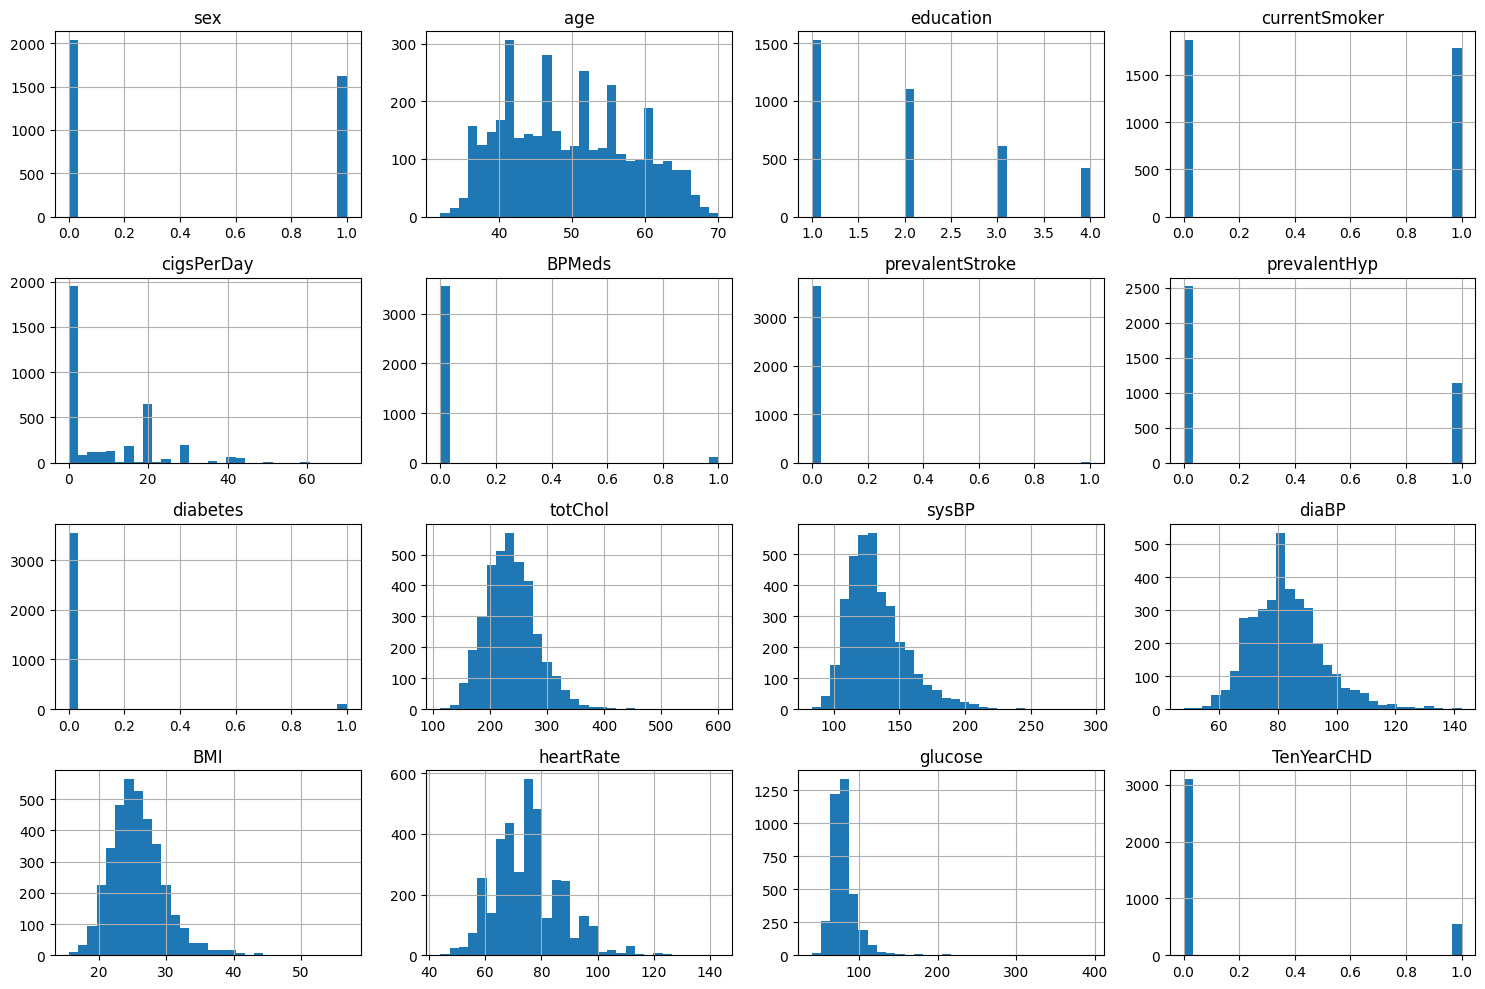

In [ ]:
#Creates histograms

df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


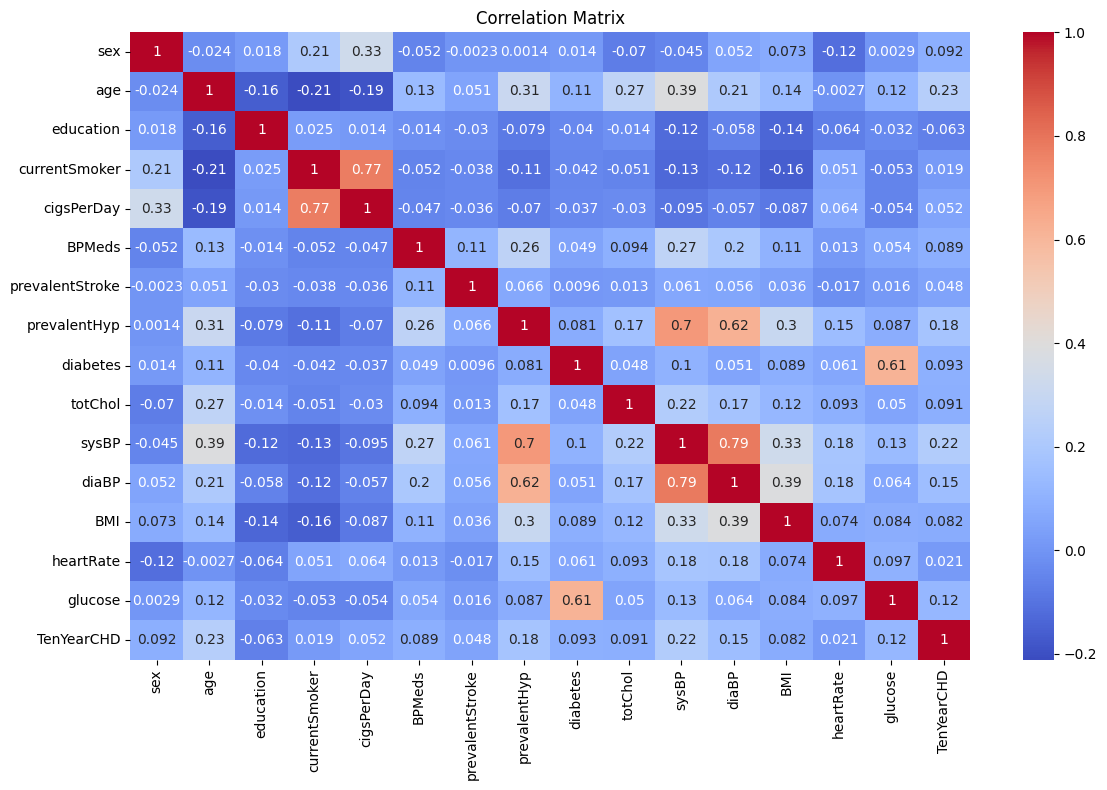

In [ ]:
#Creates heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


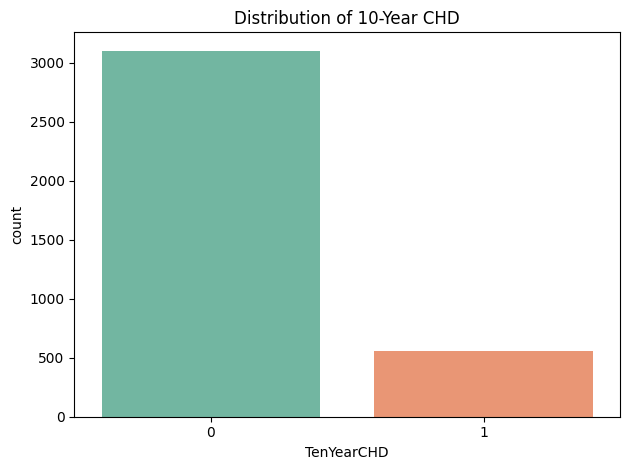

In [ ]:
#Creates a bar chart

sns.countplot(data=df, x='TenYearCHD', palette='Set2')
plt.title("Distribution of 10-Year CHD")
plt.tight_layout()
plt.show()


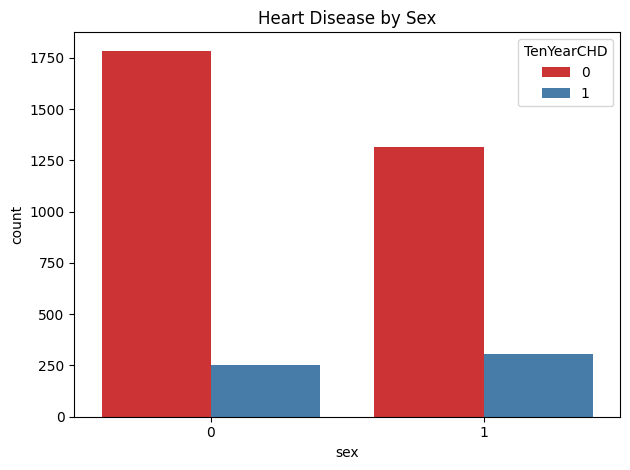

In [ ]:
#Creates a grouped bar chart
#female = 0   male = 1

sns.countplot(data=df, x='sex', hue='TenYearCHD', palette='Set1')
plt.title("Heart Disease by Sex")
plt.tight_layout()
plt.show()


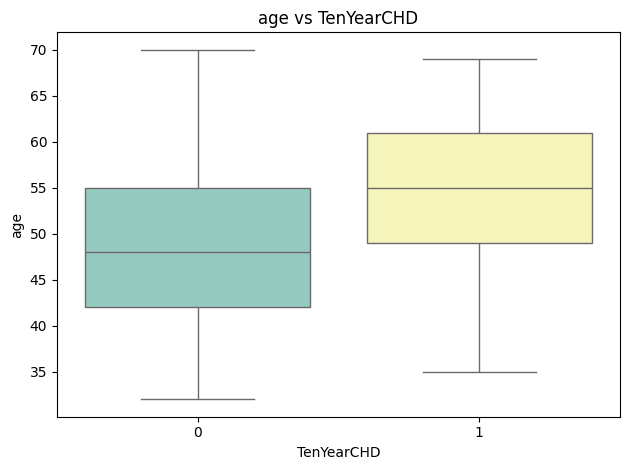

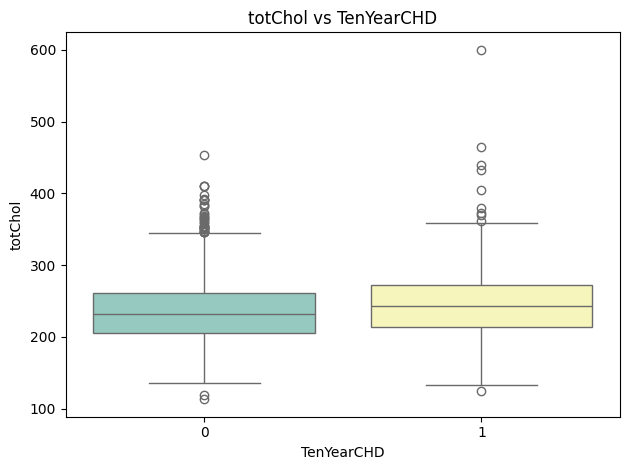

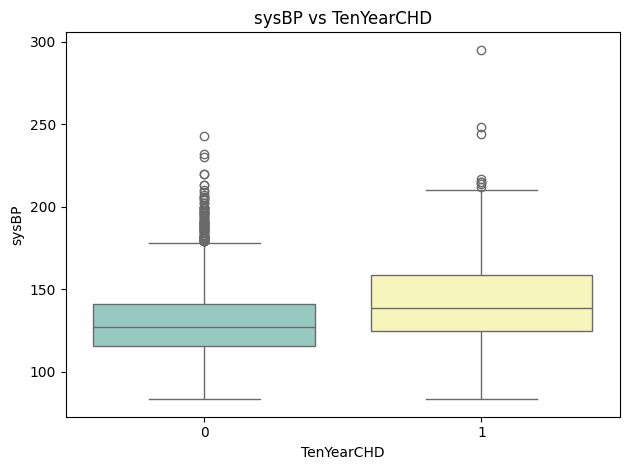

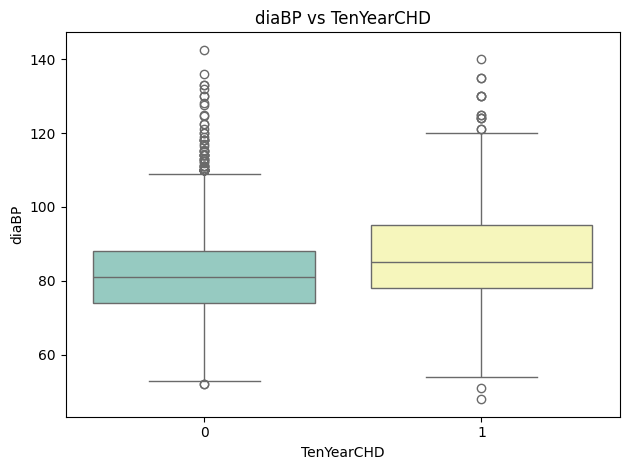

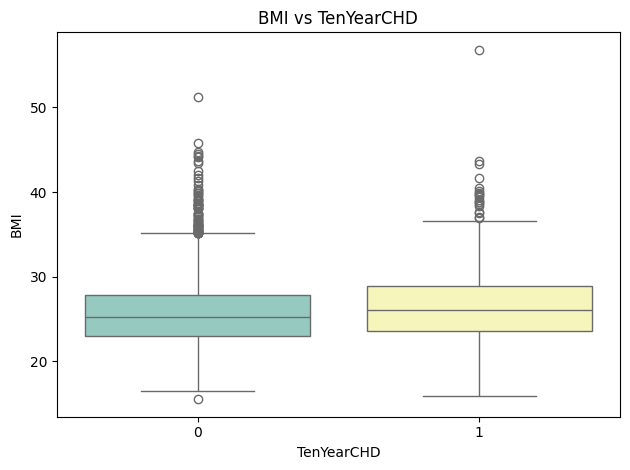

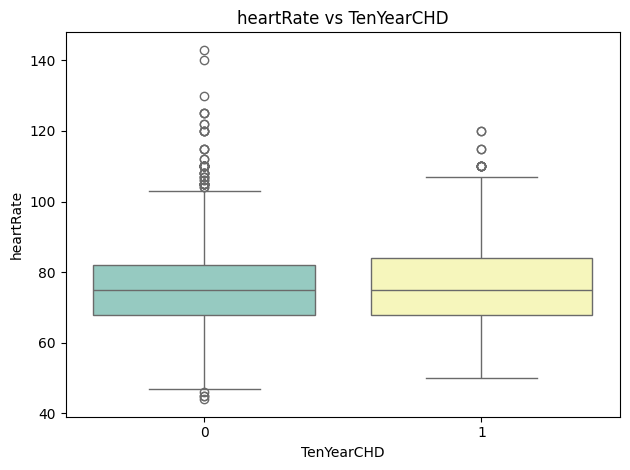

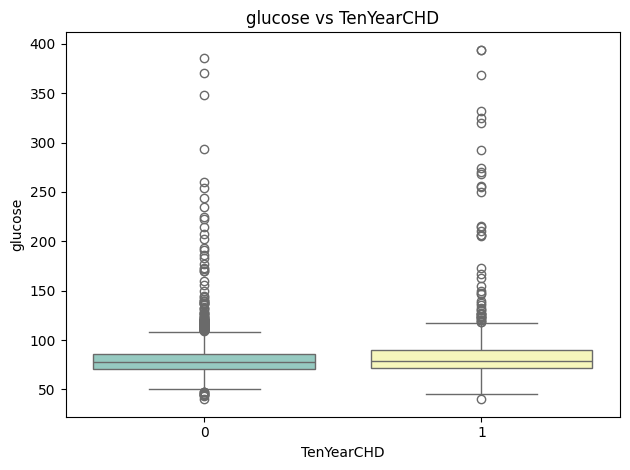

In [ ]:
#Creates a series of boxplots to visually compare the distribution of each 
#numeric health feature between people who did & did not develop CHD

num_features = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
for feature in num_features:
    sns.boxplot(data=df, x='TenYearCHD', y=feature, palette='Set3')
    plt.title(f"{feature} vs TenYearCHD")
    plt.tight_layout()
    plt.show()


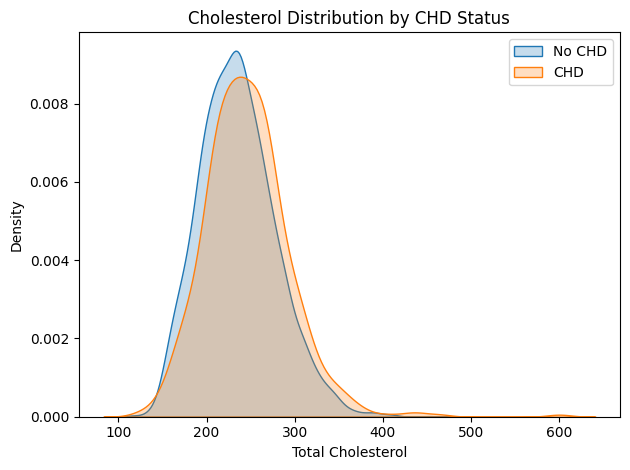

In [ ]:
#Creates a Kernel Density Estimate (KDE) plot

sns.kdeplot(data=df[df['TenYearCHD'] == 0]['totChol'], label='No CHD', fill=True)
sns.kdeplot(data=df[df['TenYearCHD'] == 1]['totChol'], label='CHD', fill=True)
plt.title("Cholesterol Distribution by CHD Status")
plt.xlabel("Total Cholesterol")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#Feature selection, standardization & train-test splitting

features = [
    'age', 'sex', 'currentSmoker', 'cigsPerDay', 'BPMeds',
    'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol',
    'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose'
]
target = 'TenYearCHD'

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [ ]:
#Trains a Logistic Regression model to predict

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8415300546448088
Confusion Matrix:
 [[607   3]
 [113   9]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91       610
           1       0.75      0.07      0.13       122

    accuracy                           0.84       732
   macro avg       0.80      0.53      0.52       732
weighted avg       0.83      0.84      0.78       732



ROC AUC Score: 0.7314834721848964


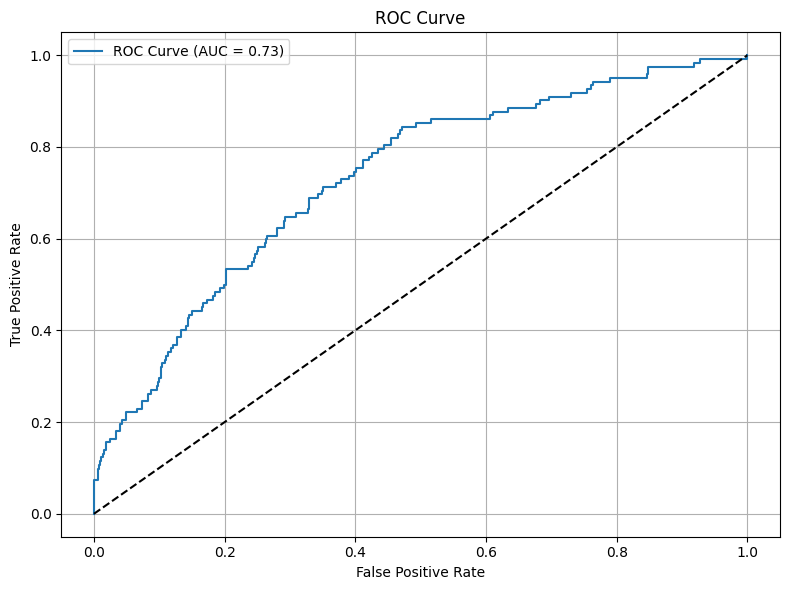

In [ ]:
#Plots the ROC curve

fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)
print("ROC AUC Score:", auc_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#Saves the trained Logistic Regression model to a file that can be reloaded 
#and used later WITHOUT retraining the model

joblib.dump(model, 'heart_disease_prediction_model.pkl')
print("Model saved as heart_disease_prediction_model.pkl")


Model saved as heart_disease_prediction_model.pkl
